# KNN modeling and the Open Asteroid Dataset
This dataset of over 800,000 known asteroids is collected from the Small Body Database maintained by the NASA's Jet Propulsion Laboratory (JPL). It contains information about each asteroid's orbit and known measurable properties. New entires are added daily and can be obtained through the NASA Open Data Portal: 
https://data.nasa.gov/dataset/jpl-small-body-database-browser 

or the JPL portal: 
https://ssd.jpl.nasa.gov/tools/sbdb_query.html

The dataset provided was obtained from Basu (2019) IJAECS, 6, 4, 2394-2835. (Feel free to use an up-to-date dataset instead!)

***The goal of this notebook is to train a KNN model to predict the classification of asteroids given some subset of available observations.*** The two classification systems we'll be testing is the classifications from the [Small Main-Belt Asteroid Spectroscopic Survey (SMASS)](http://smass.mit.edu/smass.html) and the [Tholen Asteroid Taxonomy scheme](https://ui.adsabs.harvard.edu/abs/1989aste.conf.1139T/abstract).

In [1]:
# Importing the packages required for this exercise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Data Inspection
Before you can begin building a ML model, you must first understand the data you are given and how they relate to the overarching objective of your model. Visualizing the data is always a good first step!

### Objective: 
*Start by reading in the data as a DataFrame and printing off some information, to get a feel for the type of data contained in this set. Make special note of the datatypes each entry is given as.*

In [2]:
# Reading in the data
asteroids = pd.read_csv("open_asteroid/Asteroid_Updated.csv") #input your file path

# Display the whole dataframe...
display(asteroids)

# ... or you can print a random sample to get a better feel for how much data is or is not available
print(asteroids.sample(10))

asteroids.info() # Are there any values that are of an unexpected datatype? You may want to fix that!

/var/folders/l5/_4m7d9_j7j95_8strxhsvct40000gn/T/ipykernel_12251/3306331654.py:2: DtypeWarning: Columns (0,10,15,16,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  asteroids = pd.read_csv("open_asteroid/Asteroid_Updated.csv") #input your file path


,name,a,e,i,om,w,q,ad,per_y,data_arc,...,UB,IR,spec_B,spec_T,G,moid,class,n,per,ma
0,Ceres,2.769165,0.076009,10.594067,80.305532,73.597694,2.558684,2.979647,4.608202,8822.0,...,0.426,NaN,C,G,0.12,1.594780,MBA,0.213885,1683.145708,77.372096
1,Pallas,2.772466,0.230337,34.836234,173.080063,310.048857,2.133865,3.411067,4.616444,72318.0,...,0.284,NaN,B,B,0.11,1.233240,MBA,0.213503,1686.155999,59.699133
2,Juno,2.669150,0.256942,12.988919,169.852760,248.138626,1.983332,3.354967,4.360814,72684.0,...,0.433,NaN,Sk,S,0.32,1.034540,MBA,0.226019,1592.787285,34.925016
3,Vesta,2.361418,0.088721,7.141771,103.810804,150.728541,2.151909,2.570926,3.628837,24288.0,...,0.492,NaN,V,V,0.32,1.139480,MBA,0.271609,1325.432765,95.861936
4,Astraea,2.574249,0.191095,5.366988,141.576605,358.687607,2.082324,3.066174,4.130323,63507.0,...,0.411,NaN,S,S,NaN,1.095890,MBA,0.238632,1508.600458,282.366289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839709,NaN,2.812945,0.664688,4.695700,183.310012,234.618352,0.943214,4.682676,4.717914,17298.0,...,NaN,NaN,NaN,NaN,NaN,0.032397,APO,0.208911,1723.217927,156.905910
839710,NaN,2.645238,0.259376,12.574937,1.620020,339.568072,1.959126,3.331350,4.302346,16.0,...,NaN,NaN,NaN,NaN,NaN,0.956145,MBA,0.229090,1571.431965,13.366251
839711,NaN,2.373137,0.202053,0.732484,176.499082,198.026527,1.893638,2.852636,3.655884,5.0,...,NaN,NaN,NaN,NaN,NaN,0.893896,MBA,0.269600,1335.311579,355.351127
839712,NaN,2.260404,0.258348,9.661947,204.512448,148.496988,1.676433,2.844376,3.398501,10.0,...,NaN,NaN,NaN,NaN,NaN,0.680220,MBA,0.290018,1241.302609,15.320134


          name         a         e          i          om           w  \
675482     NaN  2.597584  0.390511  30.253661  293.728087  122.991355   
585967     NaN  2.390727  0.197149   4.913007   27.352634   58.528661   
815950     NaN  2.985877  0.101163  11.921000   69.448477  302.401123   
122265     NaN  2.661302  0.234642  13.019699  262.071638   27.605519   
9482    Chagas  3.114010  0.167721   8.713514  198.630917  183.148235   
438611     NaN  2.771980  0.171695   8.430831  269.286626  197.378729   
344332     NaN  2.352674  0.132908   6.346646  309.623656   76.991401   
215843     NaN  2.951174  0.050797   3.103069   79.395896  204.205012   
255455     NaN  1.950605  0.091815  25.311511  112.737236  271.910737   
815986     NaN  2.866395  0.486763  16.063194  214.158261    5.697492   

               q        ad     per_y  data_arc  ...  UB  IR  spec_B spec_T  \
675482  1.583200  3.611969  4.186612    3022.0  ... NaN NaN     NaN    NaN   
585967  1.919398  2.862055  3.696605    

## Header descriptions

You should notice that the dataset contains 27 unique columns. Below is a brief description of what each header means. The spectral taxonomic types that we will try to predict are kept under the headers **spec_B** and **spec_T**. 
* **name**: *Object name/designation*
* **a**: *semi-major axis [AU]*
* **e**: *eccentricity*
* **G**: *magnitude slope parameter (helps predict the magnitude of brightness as a function of the solar phase angle)*
* **i**: *inclination with respect to the xy ecliptic plane*
* **om**: *longitude of the ascending node*
* **w**: *argument of perihelion*
* **q**: *perihelion distance [AU]*
* **ad**: *aphelion distance [AU]*
* **per_y**: *Orbital period (around the sun) [yrs]*
* **data-arc**: *data arc-span [d]*
* **condition_code**: *Orbit condition code (uncertainty in orbital parameters rated from 0-9, where 0 is well-known and 9 is poorly-constrained)*
* **n_obs_used**: *number of observations used*
* **H**: *absolute magnitude parameter (brightness it would have if observed 1 AU from Sun)*
* **diameter**: *asteroid diameter [km]*
* **extent**: *object bi/tri-axial ellipsoid dimensions [km]*
* **albedo**: *geometric albedo (reflectiveness on scale of 0-1, where 1 = perfect light reflection)*
* **rot_per**: *rotation period (around rotational axis) [hrs]*
* **GM**: *standard gravitational parameter (mass times gravitational constant)*
* **BV**: *color index Bmag-Vmag*
* **UB**: *color index Umag-Bmag*
* **IR**: *color index Imag-Rmag*
* **spec_B**: *spectral taxonomic type (SMASSII)*
* **spec_T**: *spectral taxonomic type (Tholen)*
* **neo**: *Near Earth Object flag (bool)*
* **pha**: *Physically Hazardous Asteroid flag (bool)*
* **moid**: *Earth Minimum Orbit Intersection Distance [AU]*

#### Orbital Parameters

The orbits of each asteroid around the sun are described in several ways within this dataset. 

The shape of an asteroid's orbit is described by the semi-major axis (a) and eccentricity (e). The eccentricity describes how circular (e = 0) or elliptical (0 < e < 1) the orbit is. The semi-major axis is its farthest distance from the center of the circle/ellipse. The semi-minor axis (closest distance from center) can be calculated as $b = a\sqrt{1-e^{2}}$, such that larger eccentricities lead to shorter semi-minor axes (could this be useful for our models?).

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/76/An_image_describing_the_semi-major_and_semi-minor_axis_of_ellipse.svg/960px-An_image_describing_the_semi-major_and_semi-minor_axis_of_ellipse.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20141026153810" width="500"/>

(Credit: Wikimedia Commons, Sae1962)

The distance between each asteroid and the sun is described through the perihelion and aphelion distances (the minimum and maximum distance along the semi-major axis of the object's orbit), as shown below: 

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Perihelion_aphelion_semimajor_axis.svg/960px-Perihelion_aphelion_semimajor_axis.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20210920195140" width="500"/>

(Credit: Wikimedia Commons, Maxmath12) 

The inclination (i), longitude of the ascending node (om), and argument of perihelion (w) together give the three-dimensional tilt in the orbit of each object, as shown below:

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Orbit1.svg/960px-Orbit1.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20230508033814" width="400"/>

(Credit: Wikipedia, Lasunncty) 

#### Brightness, Color, and Classifications

Asteroids and other small bodies may be classified in several ways based on parameters such as their brightness, reflectiveness, and colors. The SMASSII and Tholen classifications are two such systems represented in this data set (**spec_B** and **spec_T**). The definition of each classification flag can be found here: https://en.wikipedia.org/wiki/Asteroid_spectral_types

The colors of objects are calculated by subtracting their absolute magnitudes measured within any 2 color filters. Represented in this dataset are  **BV** (blue vs. green), **UB** (ultra-violet vs. blue), and **IR** (infrared vs. red). Colors can be a useful means of measuring how objects interact (or emit) light, which may help determine what type of object it is. 

This example below shows a color-color diagram of small-body populations, including Kuiper belt objects (red), comets (cyan), and asteroids of different Tholen classifications (black and white circles, with classifications marked):

<img src="small-body_CCD.png" width="400"/>

(Credit: Filacchione et al. 2022)

The amount of light reflected by an asteroid is described by a combination of the absolute magnitude parameter (H) and the geometric albedo (albedo). The albedo of an object is the ratio of the actual brightness we observe and that of a perfectly reflecting object of the same size, largely dependent on the surface material of the asteroid. For example, Saturn and its moon Titan receive the same amount of sunlight, but because Titan has a lower albedo, it appears dimmer: 

<img src="https://upload.wikimedia.org/wikipedia/commons/3/36/Titan_and_Saturn_-_May_6_2012_-_combined_%2835516187116%29.jpg" width="400"/>
(Credit: Kevin Gill) 


On the other hand, is the hypothetical brightness we would observe if the object was 1 AU from the Sun. The absolute magnitude parameter and albedo are intrinsically linked; the more reflective a given surface is, the brighter you would expect it to appear if for a given amount of sunlight.

# Feature Selection
We are building a model that can predict the SMASSII and Tholen classifications of a given asteroid using a KNN algorithm.

Based on the information provided above and within the dataset, which properties (features) would you expect to be most strongly linked to asteroid classification? Are the features the same for each classification method (SMASSII vs. Tholen)? 

### Objective: 
*Select the features that will be used for the KNN model(s) and clean up the data, removing all NaNs and infinities. Also set up your labels for each of the taxonomic classification systems.*

*NOTE: Pay close attention to the spectral classes and subclasses included in each of the classification systems. Can any of the subgroups be merged into a single class? Would that benefit your models?*

In [ ]:
### INPUT NEEDED ###
# Setting up masks to help select the features of interest
feat_list = []

### Your code here ###
# Enter any additional code needed to set up your labels and dataframes here
#

### Your code here ###
# Clean the data
#

In [14]:
### EXAMPLE SOLUTIONS ###
# Setting up masks to help select the features of interest

feat_list = ["albedo", "H", "BV", "UB", "diameter"]

# I noticed diameters are given as floats, so I'll fix that first
asteroids["diameter"] = [float(d) for d in asteroids["diameter"]]

# Cleaning the data for the classification systems
asteroids_S = asteroids.dropna(how="any", subset="spec_B").reset_index(drop=True)
asteroids_T = asteroids.dropna(how="any", subset="spec_T").reset_index(drop=True)

# Cleaning out any bad data from each DataFrame
asteroids_S = asteroids_S.dropna(how="any", subset=feat_list).reset_index(drop=True)
asteroids_T = asteroids_T.dropna(how="any", subset=feat_list).reset_index(drop=True)

# Shortening each classification in the SMASSII system to just the first letter
asteroids_S["SMASSII"] = [a[0] for a in asteroids_S["spec_B"].values.tolist()]
asteroids_T["Tholen"] = [a[0] for a in asteroids_T["spec_T"].values.tolist()]

# Setting up labels and features
labels_T = asteroids_T["Tholen"].values.tolist()
labels_S = asteroids_S["SMASSII"].values.tolist()
feats_T = asteroids_T[feat_list]
feats_S = asteroids_S[feat_list]

display(asteroids_S), display(asteroids_T)
asteroids_S.info()

,name,a,e,i,om,w,q,ad,per_y,data_arc,...,IR,spec_B,spec_T,G,moid,class,n,per,ma,SMASSII
0,Ceres,2.769165,0.076009,10.594067,80.305532,73.597694,2.558684,2.979647,4.608202,8822.0,...,NaN,C,G,0.12,1.594780,MBA,0.213885,1683.145708,77.372096,C
1,Pallas,2.772466,0.230337,34.836234,173.080063,310.048857,2.133865,3.411067,4.616444,72318.0,...,NaN,B,B,0.11,1.233240,MBA,0.213503,1686.155999,59.699133,B
2,Juno,2.669150,0.256942,12.988919,169.852760,248.138626,1.983332,3.354967,4.360814,72684.0,...,NaN,Sk,S,0.32,1.034540,MBA,0.226019,1592.787285,34.925016,S
3,Vesta,2.361418,0.088721,7.141771,103.810804,150.728541,2.151909,2.570926,3.628837,24288.0,...,NaN,V,V,0.32,1.139480,MBA,0.271609,1325.432765,95.861936,V
4,Astraea,2.574249,0.191095,5.366988,141.576605,358.687607,2.082324,3.066174,4.130323,63507.0,...,NaN,S,S,NaN,1.095890,MBA,0.238632,1508.600458,282.366289,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,Nefertiti,1.574459,0.284146,32.961617,340.006630,53.407775,1.127083,2.021836,1.975629,13434.0,...,NaN,Sq,S,NaN,0.215293,AMO,0.498892,721.598353,161.248569,S
444,Seleucus,2.033192,0.456059,5.930310,218.651696,349.326086,1.105937,2.960447,2.899184,13457.0,...,NaN,K,S,NaN,0.102357,AMO,0.339967,1058.926989,281.105247,K
445,Beckman,2.405732,0.396780,20.132924,288.193198,85.509257,1.451187,3.360277,3.731462,13057.0,...,NaN,S,NaN,NaN,0.608986,MCA,0.264139,1362.916483,179.543635,S
446,NaN,2.235406,0.516212,6.378794,241.309584,213.653119,1.081463,3.389348,3.342280,11110.0,...,NaN,V,QU,NaN,0.112894,AMO,0.294896,1220.767667,174.592542,V


,name,a,e,i,om,w,q,ad,per_y,data_arc,...,IR,spec_B,spec_T,G,moid,class,n,per,ma,Tholen
0,Ceres,2.769165,0.076009,10.594067,80.305532,73.597694,2.558684,2.979647,4.608202,8822.0,...,NaN,C,G,0.12,1.594780,MBA,0.213885,1683.145708,77.372096,G
1,Pallas,2.772466,0.230337,34.836234,173.080063,310.048857,2.133865,3.411067,4.616444,72318.0,...,NaN,B,B,0.11,1.233240,MBA,0.213503,1686.155999,59.699133,B
2,Juno,2.669150,0.256942,12.988919,169.852760,248.138626,1.983332,3.354967,4.360814,72684.0,...,NaN,Sk,S,0.32,1.034540,MBA,0.226019,1592.787285,34.925016,S
3,Vesta,2.361418,0.088721,7.141771,103.810804,150.728541,2.151909,2.570926,3.628837,24288.0,...,NaN,V,V,0.32,1.139480,MBA,0.271609,1325.432765,95.861936,V
4,Astraea,2.574249,0.191095,5.366988,141.576605,358.687607,2.082324,3.066174,4.130323,63507.0,...,NaN,S,S,NaN,1.095890,MBA,0.238632,1508.600458,282.366289,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,Verenia,2.093062,0.487037,9.507940,173.813900,193.229338,1.073664,3.112459,3.028177,13049.0,...,NaN,NaN,V,NaN,0.074739,AMO,0.325485,1106.041474,272.020676,V
887,Anagolay,1.834657,0.446081,3.868004,74.963978,17.208087,1.016252,2.653063,2.485082,13428.0,...,NaN,NaN,S,NaN,0.036713,APO,0.396617,907.676120,220.409784,S
888,Wilson-Harrington,2.626611,0.630864,2.798293,266.818677,95.388208,0.969577,4.283646,4.256983,25304.0,...,NaN,NaN,CF,NaN,0.043087,APO,0.231532,1554.863175,78.365833,C
889,NaN,2.235406,0.516212,6.378794,241.309584,213.653119,1.081463,3.389348,3.342280,11110.0,...,NaN,V,QU,NaN,0.112894,AMO,0.294896,1220.767667,174.592542,Q


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            447 non-null    object 
 1   a               448 non-null    float64
 2   e               448 non-null    float64
 3   i               448 non-null    float64
 4   om              448 non-null    float64
 5   w               448 non-null    float64
 6   q               448 non-null    float64
 7   ad              448 non-null    float64
 8   per_y           448 non-null    float64
 9   data_arc        448 non-null    float64
 10  condition_code  448 non-null    object 
 11  n_obs_used      448 non-null    int64  
 12  H               448 non-null    float64
 13  neo             448 non-null    object 
 14  pha             448 non-null    object 
 15  diameter        448 non-null    float64
 16  extent          10 non-null     object 
 17  albedo          448 non-null    flo

### Objective: 
*Make a few plots to determine how many of each class are in each cleaned dataset, and the range of values they span for each selected feature. Keep in mind how this may affect your models!*

In [ ]:
### Your code here ###
#
#


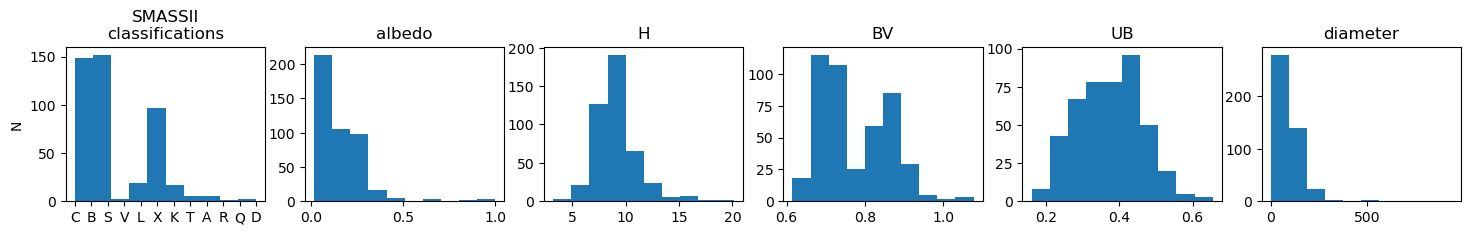

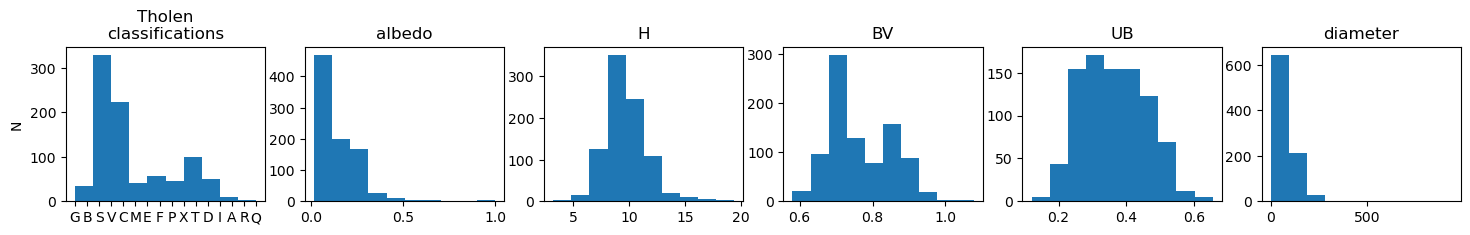

In [4]:
### EXAMPLE SOLUTIONS ###

# Plotting the SMASSII classifications and properties
fig1, axes1 = plt.subplots(1,6, figsize=(18,2))
axes1[0].set_title("SMASSII\nclassifications")
axes1[0].hist(asteroids_S["SMASSII"])
axes1[0].set_ylabel("N")
for i,f in enumerate(feat_list):
    axes1[i+1].set_title(f"{f}")
    axes1[i+1].hist(asteroids_S[f])
plt.show()

# Plotting the Tholen classifications and properties
fig2, axes2 = plt.subplots(1,6, figsize=(18,2))
axes2[0].set_title("Tholen\nclassifications")
axes2[0].hist(asteroids_T["Tholen"])
axes2[0].set_ylabel("N")
for i,f in enumerate(feat_list):
    axes2[i+1].set_title(f"{f}")
    axes2[i+1].hist(asteroids_T[f])
plt.show()


# First-pass model
At this point, you should have one or two DataFrames containing a clean dataset for the SMASSII/Tholen classification model(s). It's time to build the K-Nearest Neighbors model! We'll start by feeding in the selected data into the model without making alterations to the data. Later, we can see how feature engineering may improve the results. 

### Objective:
*Train a KNN model for each classification type, based only on the features selected.*

*REMEMBER: Your data must be scaled in order for the KNN to work properly!*

In [ ]:
### INPUT NEEDED ###
# Building the training and test set
= train_test_split( , # feature DataFrame or Array, 
                    , # labels DataFrame or Array
                   test_size = , # fractional size of your test set (or use train_size)
                   random_state= ) # controls random number generator for consistent compilations

# Standardizing the feature scaling using z-scores
scaler = StandardScaler()
 = scaler.fit_transform( # Input training features and save to variable
 = scaler.fit_transform( # Input test features and save to variable

# Setting up the classifier
knn = KNeighborsClassifier( # Set up parameters for your KNN

# Training the classifier 
knn.fit( # Train the KNN on the rescaled training set

# Testing model
predict_test = knn.predict( # Test the KNN on the rescaled test set

# plotting accuracy
acc = accuracy_score( # Input expected vs. predicted labels to calculate the accuracy of the model
print(f"Accuracy: {round(acc*100, 1)}%")

### How else can you explore the accuracy of the model(s)? ###
### Do you need to repeat this for each model? ###
### Your extra code here ###
#
    

SMASSII Accuracy: 70.6% out of 180 asteroids


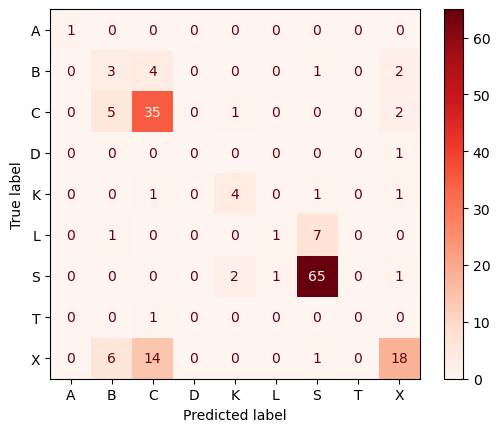

Tholen Accuracy: 66.4% out of 357 asteroids


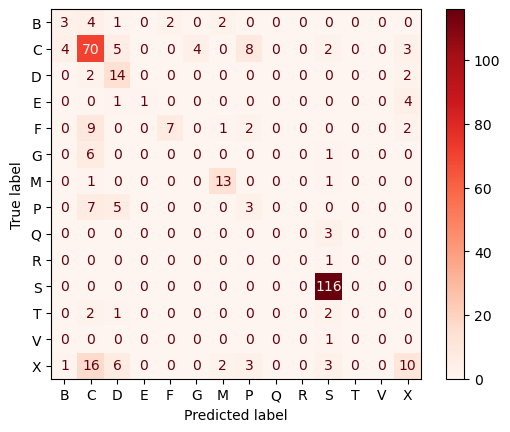

In [5]:
### EXAMPLE SOLUTIONS ###

# Training the models separately
feats_train_S, feats_test_S, labels_train_S, labels_test_S = train_test_split(feats_S, labels_S,test_size = 0.4, random_state=0) 
feats_train_T, feats_test_T, labels_train_T, labels_test_T = train_test_split(feats_T, labels_T, test_size = 0.4, random_state=0) 

# Standardizing the feature scaling using z-scores
scaler = StandardScaler()
feats_train_S_scaled = scaler.fit_transform(feats_train_S) 
feats_test_S_scaled = scaler.fit_transform(feats_test_S)
feats_train_T_scaled = scaler.fit_transform(feats_train_T)
feats_test_T_scaled = scaler.fit_transform(feats_test_T)

# Setting up the classifier
knn_S = KNeighborsClassifier(n_neighbors=3)
knn_T = KNeighborsClassifier(n_neighbors=3)

# Training the classifiers
knn_S.fit(feats_train_S_scaled, labels_train_S)
knn_T.fit(feats_train_T_scaled, labels_train_T)

# Testing model with rescaled data
predict_test_S = knn_S.predict(feats_test_S_scaled)
predict_test_T = knn_T.predict(feats_test_T_scaled)

# plotting accuracy
acc_S = accuracy_score(labels_test_S, predict_test_S)
acc_T = accuracy_score(labels_test_T, predict_test_T)

print(f"SMASSII Accuracy: {round(acc_S*100, 1)}% out of {len(predict_test_S)} asteroids")
ConfusionMatrixDisplay.from_predictions(labels_test_S, predict_test_S, cmap="Reds")
plt.show()


print(f"Tholen Accuracy: {round(acc_T*100, 1)}% out of {len(predict_test_T)} asteroids")
ConfusionMatrixDisplay.from_predictions(labels_test_T, predict_test_T, cmap="Reds")
plt.show()

### Objective: 
*Create a series of scatterplots with different features for the x- and y-axes, with the markers colored by classification to show neighborship clustering. Can you tell by eye how why the model is clustering the asteroids as it is?*

In [ ]:
### Your code here ###
#
#

Plotting SMASSII features and labels
SMASSII Actual Classifications


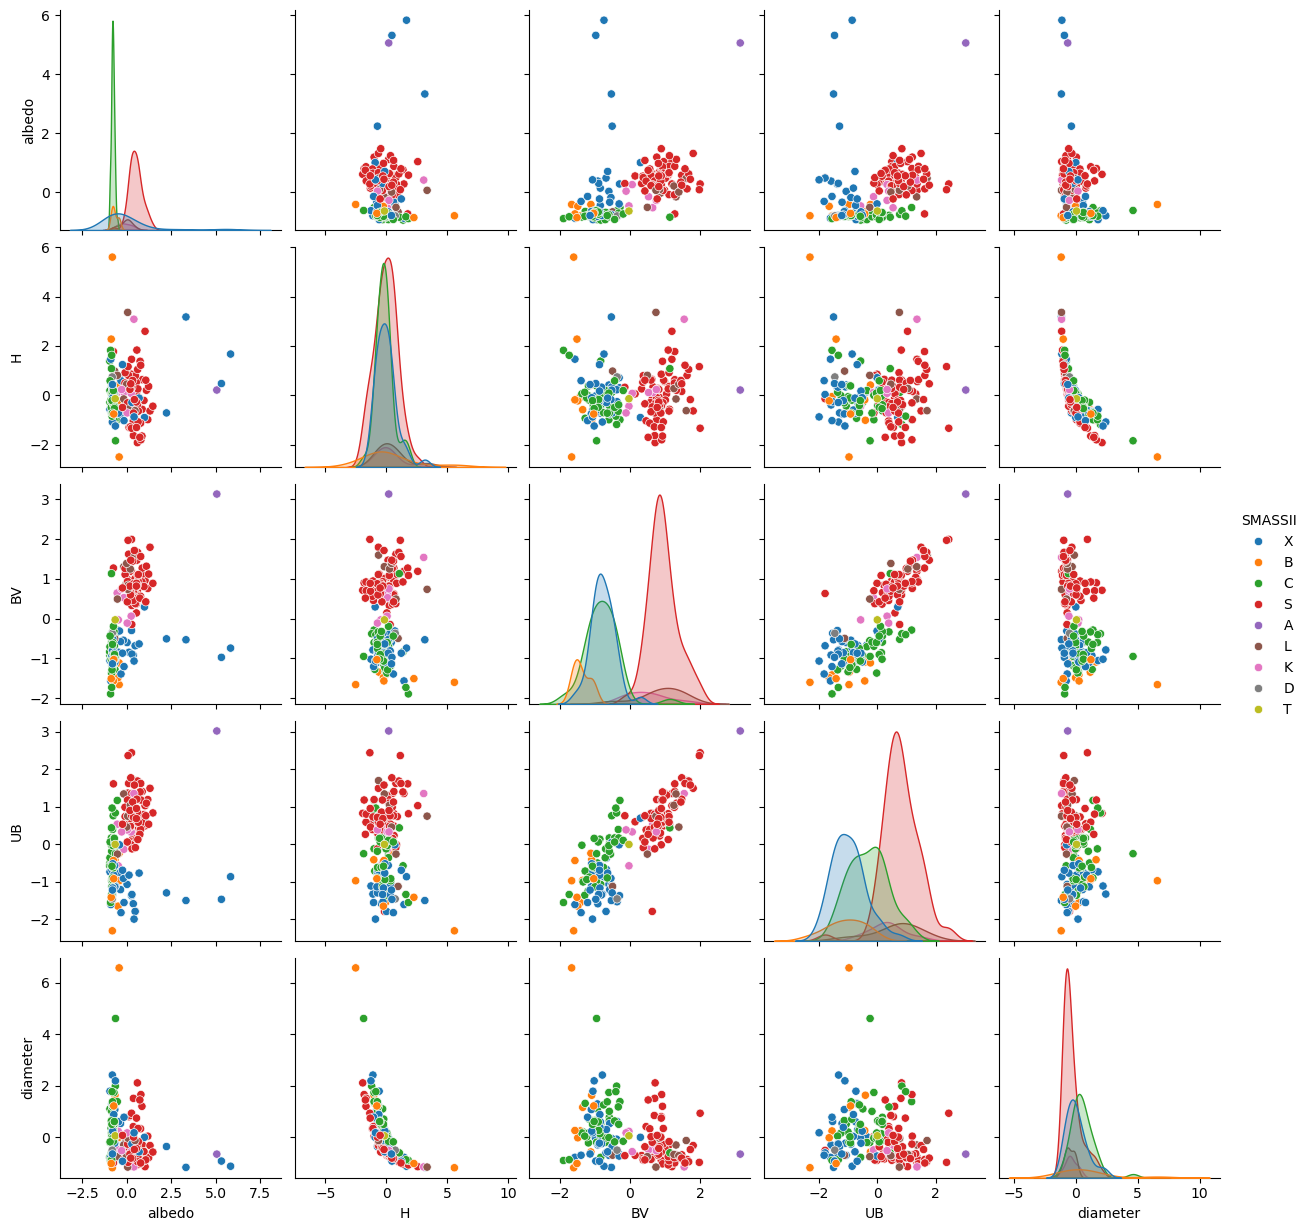

SMASSII Predicted Classifications


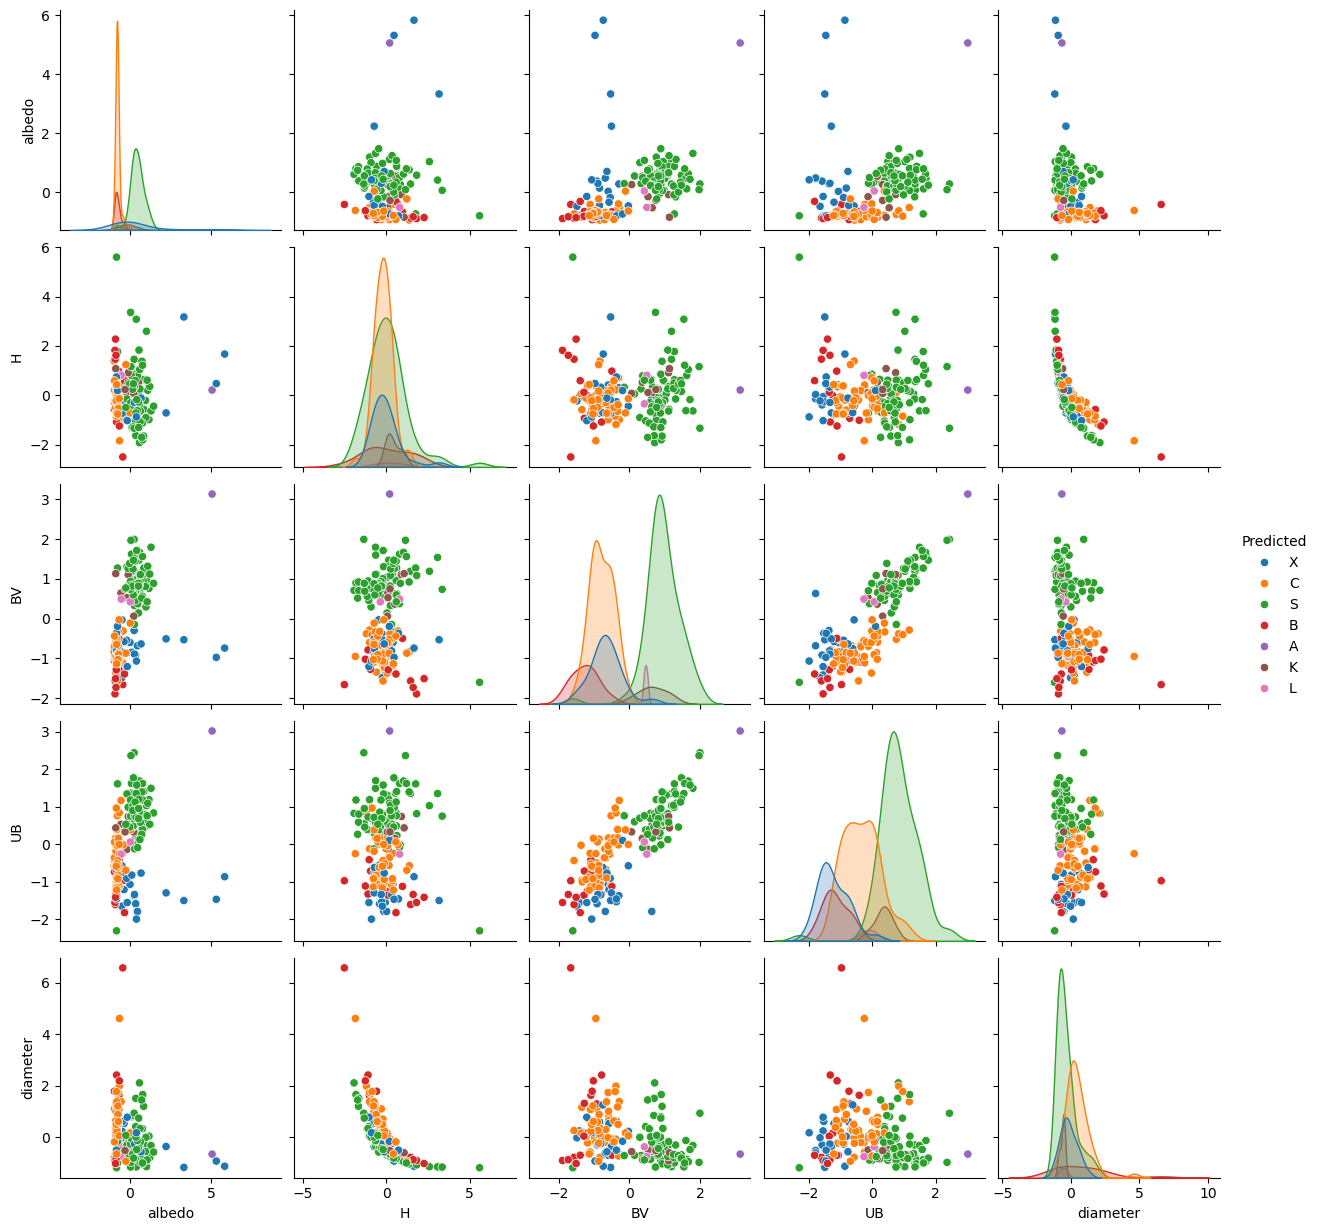

Plotting Tholen features and labels
Tholen Actual Classifications


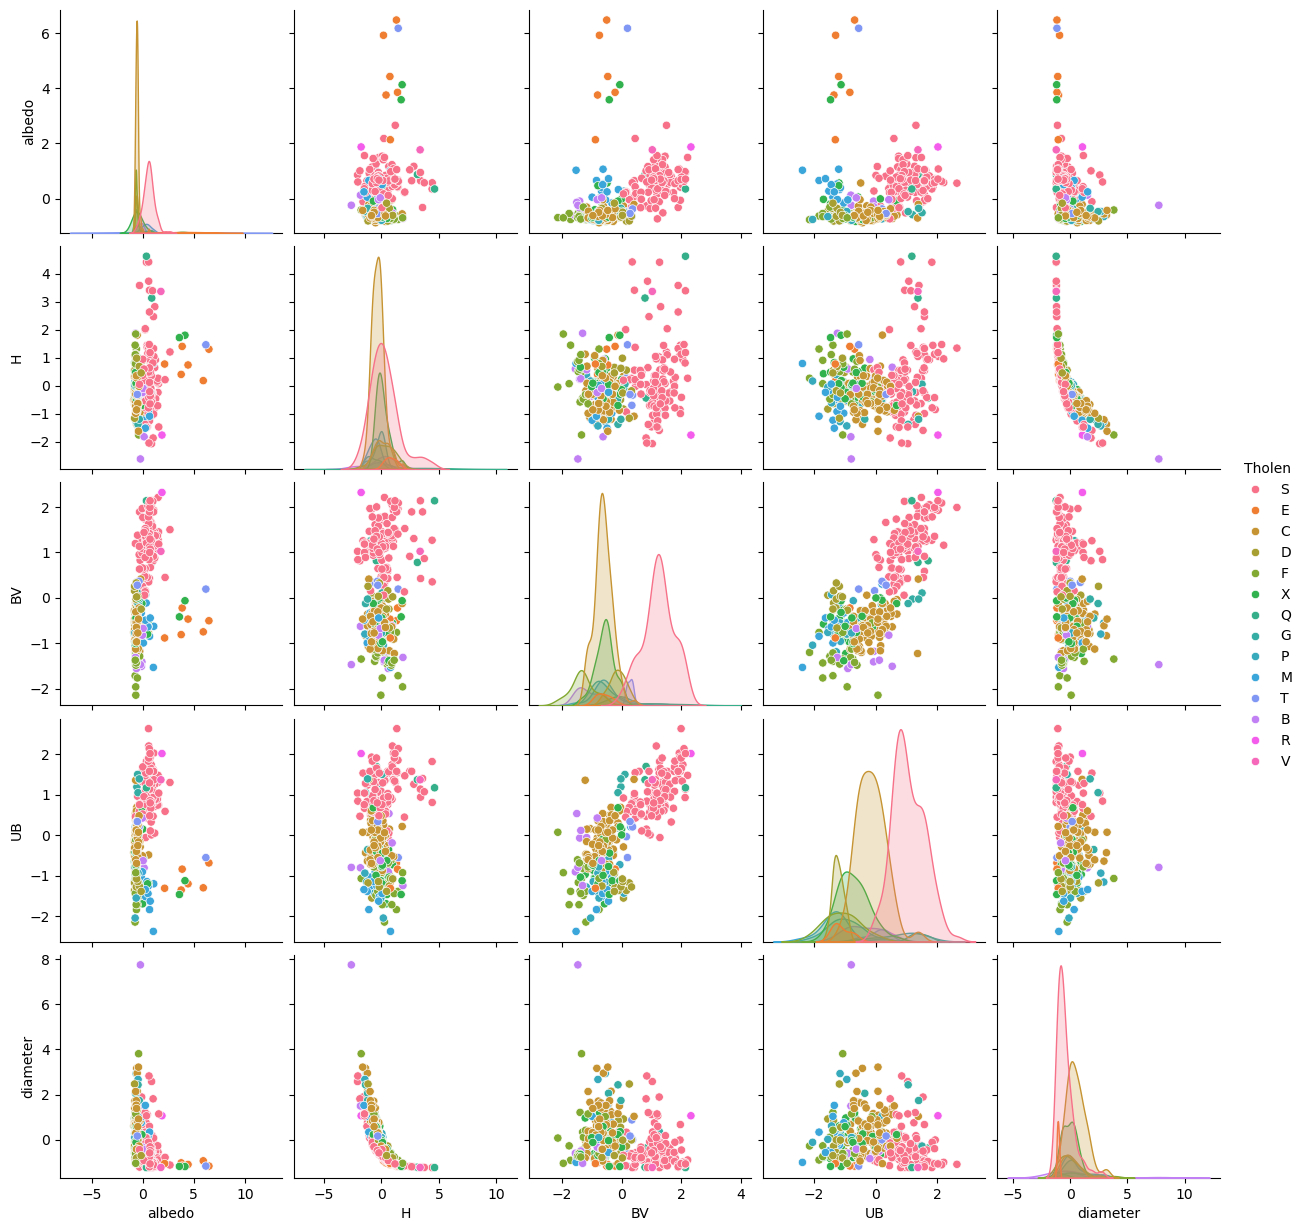

Tholen Predicted Classifications


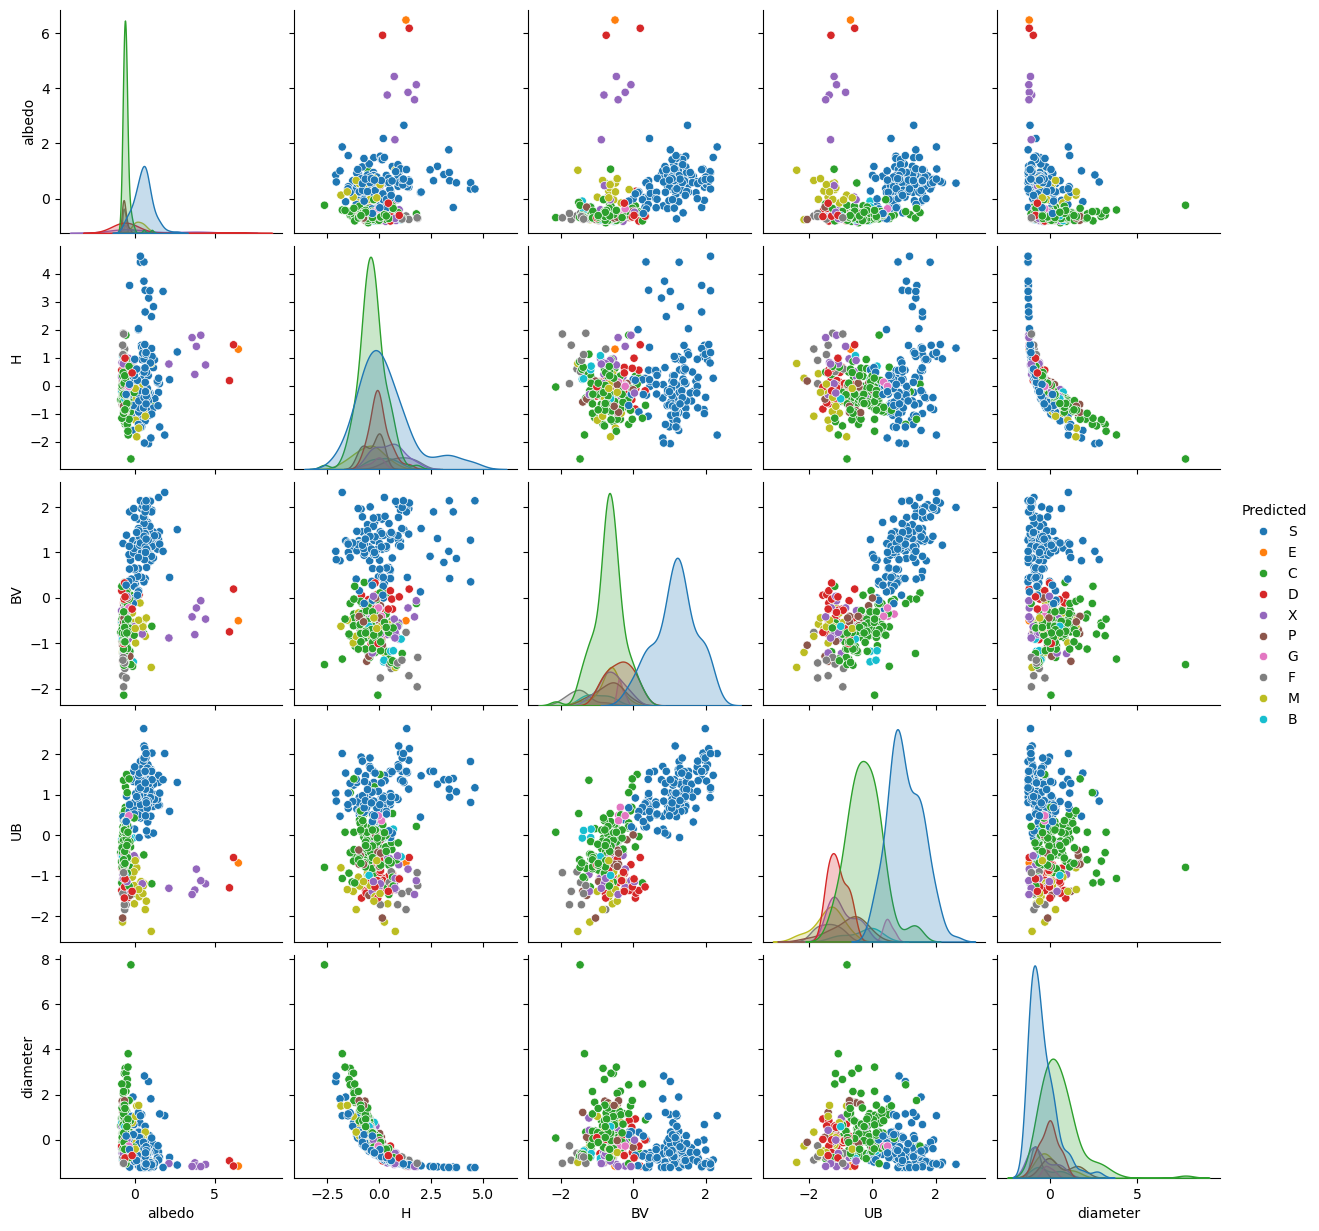

In [6]:
### EXAMPLE SOLUTIONS ###
# I've chosen to use seaborn to make pair plots with classifications shown

import seaborn as sns

# Building dedicated DataFrames with only model informations
data_S = [d.tolist() + [labels_test_S[i]] + [predict_test_S[i]] for i,d in enumerate(feats_test_S_scaled)]
model_S = pd.DataFrame(data=data_S, columns=feat_list+["SMASSII"]+["Predicted"])

data_T = [d.tolist() + [labels_test_T[i]] + [predict_test_T[i]] for i,d in enumerate(feats_test_T_scaled)]
model_T = pd.DataFrame(data=data_T, columns=feat_list+["Tholen"]+["Predicted"])

print("Plotting SMASSII features and labels") 
print("SMASSII Actual Classifications")
sns.pairplot(model_S, hue="SMASSII")
plt.show()
print("SMASSII Predicted Classifications")
sns.pairplot(model_S, hue="Predicted")
plt.show()

print("Plotting Tholen features and labels") 
print("Tholen Actual Classifications")
sns.pairplot(model_T, hue="Tholen")
plt.show()
print("Tholen Predicted Classifications")
sns.pairplot(model_T, hue="Predicted")
plt.show()

# Improving the Model

Chances are, the first-pass model isn't the most accurate or efficient model you could build for these data. There are a few techniques you can try to improve it. First, models can be optimized such that you are using the best combination of parameters when building the KNN and the most important features during the 'training' step. You can also attempt to engineer new features (as we've done before). 

## Model Optimization

You can optimize your KNN using [`sklearn.model_selection.GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to determine which combination of parameters from a provided list results in the best, most efficient model. It works by reading in the type of classifier and a library of parameters and potential values for those parameters. You then fit the grid to your data as you would any other `sklearn` ML model and print off the best-fit parameters. **NOTE: `GridSearchCV` may not work if you have a category that contains a small number of members compared to the number of neighbors in your KNN model.** There may be ways to work around this limitation, if you're determined to use it anyway.

### Objective: 
*Use `GridSearchCV` to optimize your KNN for each set of data (SMASSII and Tholen). Do the best parameters differ between the two? Does applying these parameters to your KNN improve your models?*

In [ ]:
### INPUT NEEDED ###
print("Creating grid...")

grid_results = GridSearchCV(KNeighborsClassifier(), 
                            {'n_neighbors': , # a list of the different numbers of neighbors to test 
                             'algorithm': ['ball_tree', 'kd_tree'], # types of algorithms to test. 'brute' is also an option
                             'leaf_size': , # a list of leaf sized to test
                             'weights': ['uniform', 'distance']} # weighting methods to test
                            )

starttime=time.perf_counter() # counter for timing
print("Fitting grid...")
grid_results.fit( # Insert your training and test data to fit
endtime = time.perf_counter()
print(f"Run time: {round((endtime-starttime)/60, 3)} mins")
print('The best model has {}'.format(grid_results.best_params_))


In [ ]:
### Test these parameters in a KNN and compare to your previous model ###
#
#

In [7]:
### EXAMPLE SOLUTIONS ###
grid_results_S = GridSearchCV(KNeighborsClassifier(), 
                            {'n_neighbors': [1,2,3,5,10,50], 
                             'algorithm': ['ball_tree', 'kd_tree'], 
                             'leaf_size': [2,5,10,50], 
                             'weights': ['uniform', 'distance']} 
                           )
grid_results_T = GridSearchCV(KNeighborsClassifier(), 
                            {'n_neighbors': [1,2,3,5,10,50], 
                             'algorithm': ['ball_tree', 'kd_tree'], 
                             'leaf_size': [2,5,10,50], 
                             'weights': ['uniform', 'distance']} 
                           )

print("Fitting SMASSII grid...")
grid_results_S.fit(feats_train_S_scaled, labels_train_S)
print('The best SMASSII model has {}'.format(grid_results_S.best_params_))

print("\nFitting Tholen grid...")
grid_results_T.fit(feats_train_T_scaled, labels_train_T)
print('The best Tholen model has {}'.format(grid_results_T.best_params_))

Fitting SMASSII grid...


/Users/qianahunt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


The best SMASSII model has {'algorithm': 'ball_tree', 'leaf_size': 2, 'n_neighbors': 10, 'weights': 'distance'}

Fitting Tholen grid...


/Users/qianahunt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


The best Tholen model has {'algorithm': 'ball_tree', 'leaf_size': 2, 'n_neighbors': 10, 'weights': 'distance'}


SMASSII Accuracy: 70.6% out of 180 asteroids


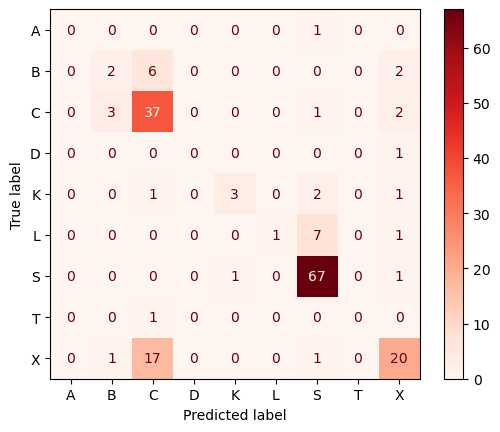

Tholen Accuracy: 66.4% out of 357 asteroids


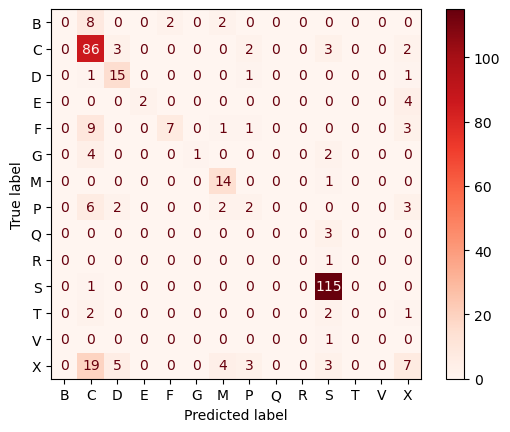

In [8]:
### EXAMPLE SOLUTIONS ###
### Testing on KNN    ###

# Setting up the classifier
knn_S_opti = KNeighborsClassifier(n_neighbors=10, algorithm="ball_tree", leaf_size=2, weights="distance")
knn_T_opti = KNeighborsClassifier(n_neighbors=10, algorithm="ball_tree", leaf_size=2, weights="distance")

# Training the classifiers
knn_S_opti.fit(feats_train_S_scaled, labels_train_S)
knn_T_opti.fit(feats_train_T_scaled, labels_train_T)

# Testing model with rescaled data
predict_test_S_opti = knn_S_opti.predict(feats_test_S_scaled)
predict_test_T_opti = knn_T_opti.predict(feats_test_T_scaled)

# plotting accuracy
acc_S_opti = accuracy_score(labels_test_S, predict_test_S)
acc_T_opti = accuracy_score(labels_test_T, predict_test_T)

print(f"SMASSII Accuracy: {round(acc_S_opti*100, 1)}% out of {len(predict_test_S_opti)} asteroids")
ConfusionMatrixDisplay.from_predictions(labels_test_S, predict_test_S_opti, cmap="Reds")
plt.show()


print(f"Tholen Accuracy: {round(acc_T_opti*100, 1)}% out of {len(predict_test_T_opti)} asteroids")
ConfusionMatrixDisplay.from_predictions(labels_test_T, predict_test_T_opti, cmap="Reds")
plt.show()

### I notice no change with this data. Might that be different with a larger dataset? ###

Another useful tool is [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html) from `sklearn.inspection` (which we have used before!). As a reminder, this function determines the average "importance" of each feature by applying random permutations to the features and evaluating how the model prediction changes in response. Higher mean importance values point to the most important features in the model. This can help you reduce your feature list, thereby (potentially) reducing confusion for the model.

It's worth noting that this function is much slower with KNNs than with simpler models, like linear regression, especially if you have a large dataset. The datasets used here will probably not take long to run, but for much larger sets, it's a good idea to time `permutation_importance` to decide whether it's worth running multiple times. 

### Objective:
*Determine which features are most important for determining your asteroid diameters (you may learn more about the `permutation_importance` function [here](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html), or use a different strategy to assess importance). Are there features you should remove from or add to your list? Explore how using different features change the results of your models.*

In [ ]:
### INPUT NEEDED ###

starttime = time.perf_counter() # timing permutation_importance. This may take a long time to run!
results = permutation_importance(estimator= , # your trained model
                                 X = , # data on which the importrance will be computed
                                 y = , # targets for supervised learning
                                 #scoring = , # name of scoring mechanism to use
                                 n_repeats = , # number of permutations to apply
                                 #n_jobs = , # number of parallel jobs
                                 #sample_weight = # sample weights used in scoring
                                 #max_samples = # number of samples to draw from X in each repeat
                                 random_state= ) # pseudo-random number generator

endtime = time.perf_counter()
print(f"Run time: {round((endtime-starttime)/60, 3)} mins")

# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended
print("\nFEATURE IMPORTANCE (mean +/- std)\n------------------\n")
for i in results.importances_mean.argsort()[::-1]:
        print(f"{feat_list[i]:<8}"
              f"{results.importances_mean[i]:.3f}"
              f" +/- {results.importances_std[i]:.3f}")


In [12]:
### EXAMPLE SOLUTIONS ###

print("Testing feature importance for optimized SMASSII model")
starttime = time.perf_counter()
results = permutation_importance(estimator=knn_S_opti, # your trained model
                                 X = feats_train_S_scaled, # data on which the importrance will be computed
                                 y = labels_train_S, # targets for supervised learning
                                 n_repeats = 100, # number of permutations to apply
                                 random_state= 0) # pseudo-random number generator
endtime = time.perf_counter()
print(f"Run time: {round((endtime-starttime)/60, 3)} mins")
# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended

print("\nSMASSII FEATURE IMPORTANCE (mean +/- std)\n------------------\n")
for i in results.importances_mean.argsort()[::-1]:
        print(f"{feat_list[i]:<15}"
              f"{results.importances_mean[i]:.3f}"
              f" +/- {results.importances_std[i]:.3f}")


print("\n\nTesting feature importance for optimized Tholen model")
starttime = time.perf_counter()
results = permutation_importance(estimator=knn_T_opti, # your trained model
                                 X = feats_train_T_scaled, # data on which the importrance will be computed
                                 y = labels_train_T, # targets for supervised learning
                                 n_repeats = 100, # number of permutations to apply
                                 random_state= 0) # pseudo-random number generator
endtime = time.perf_counter()
print(f"Run time: {round((endtime-starttime)/60, 3)} mins")
# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended

print("\nTHOLEN FEATURE IMPORTANCE (mean +/- std)\n------------------\n")
for i in results.importances_mean.argsort()[::-1]:
        print(f"{feat_list[i]:<15}"
              f"{results.importances_mean[i]:.3f}"
              f" +/- {results.importances_std[i]:.3f}")


Testing feature importance for optimized SMASSII model
Run time: 0.008 mins

SMASSII FEATURE IMPORTANCE (mean +/- std)
------------------

BV             0.395 +/- 0.024
UB             0.345 +/- 0.019
albedo         0.309 +/- 0.023
diameter       0.209 +/- 0.012
H              0.205 +/- 0.014


Testing feature importance for optimized Tholen model
Run time: 0.019 mins

THOLEN FEATURE IMPORTANCE (mean +/- std)
------------------

BV             0.401 +/- 0.015
UB             0.392 +/- 0.016
albedo         0.299 +/- 0.016
H              0.259 +/- 0.011
diameter       0.238 +/- 0.011


## Feature Engineering
Sometimes combining or altering the data in the set can result in a more accurate model! The results from `permutation_importance` or other sources on the SMASSII and/or Tholen system(s) may point you towards new features that can be added to your model. Keep in mind, any engineered features should be done to the original, un-scaled values and scaled afterward.

### Objective: 
*Create and test some engineered features. Compare you new model(s) to your old model(s). Which perform better for these data?* 

In [ ]:
### Your code here ###
#
#

,albedo,H,BV,UB,diameter,UV,sqrt_albedo,10^(-H)
355,0.0420,9.19,0.695,0.335,94.522,1.030,0.204939,6.456542e-10
176,0.3420,6.54,0.852,0.451,144.626,1.303,0.584808,2.884032e-07
198,0.0390,8.18,0.739,0.383,155.659,1.122,0.197484,6.606934e-09
116,0.0670,7.49,0.685,0.392,162.515,1.077,0.258844,3.235937e-08
168,0.2420,9.22,0.891,0.386,35.752,1.277,0.491935,6.025596e-10
...,...,...,...,...,...,...,...,...
323,0.0960,10.30,0.770,0.391,35.758,1.161,0.309839,5.011872e-11
192,0.2082,12.48,0.918,0.596,9.300,1.514,0.456289,3.311311e-13
117,0.1510,7.07,0.717,0.245,113.000,0.962,0.388587,8.511380e-08
47,0.1050,7.35,0.789,0.482,138.159,1.271,0.324037,4.466836e-08


,albedo,H,BV,UB,diameter,UV,sqrt_albedo,10^(-H)
100,0.0510,9.26,0.726,0.371,82.595,1.097,0.225832,5.495409e-10
722,0.0890,10.92,0.785,0.475,26.336,1.260,0.298329,1.202264e-11
678,0.0500,7.93,0.794,0.241,114.624,1.035,0.223607,1.174898e-08
229,0.1930,8.62,0.990,0.602,50.891,1.592,0.439318,2.398833e-09
334,0.0370,9.01,0.675,0.333,94.970,1.008,0.192354,9.772372e-10
...,...,...,...,...,...,...,...,...
835,0.2500,12.68,0.871,0.422,8.498,1.293,0.500000,2.089296e-13
192,0.0400,8.43,0.720,0.233,85.877,0.953,0.200000,3.715352e-09
629,0.0190,12.57,0.621,0.227,17.321,0.848,0.137840,2.691535e-13
559,0.0480,9.10,0.706,0.284,91.672,0.990,0.219089,7.943282e-10



----------------------------

SMASSII FEATURE IMPORTANCE (mean +/- std)
------------------

UB             0.289 +/- 0.018
sqrt_albedo    0.284 +/- 0.021
BV             0.284 +/- 0.018
UV             0.236 +/- 0.013
albedo         0.196 +/- 0.015
diameter       0.195 +/- 0.011
H              0.193 +/- 0.013
10^(-H)        0.006 +/- 0.002

THOLEN FEATURE IMPORTANCE (mean +/- std)
------------------

UB             0.327 +/- 0.014
BV             0.310 +/- 0.011
sqrt_albedo    0.288 +/- 0.014
UV             0.254 +/- 0.011
H              0.233 +/- 0.010
diameter       0.212 +/- 0.009
albedo         0.210 +/- 0.013
10^(-H)        0.005 +/- 0.001

---------------------
SMASSII Accuracy: 72.8% out of 180 asteroids
Accuracy change: 2.2% points


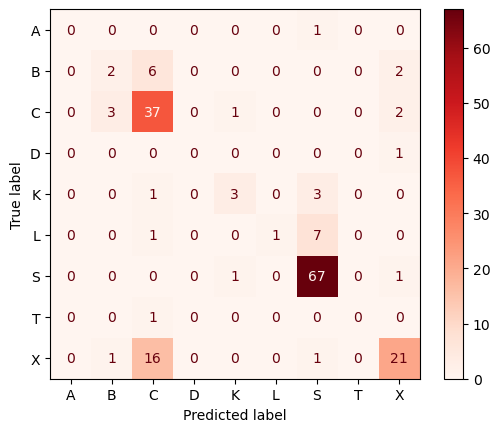

Tholen Accuracy: 69.2% out of 357 asteroids
Accuracy change: 2.8% points


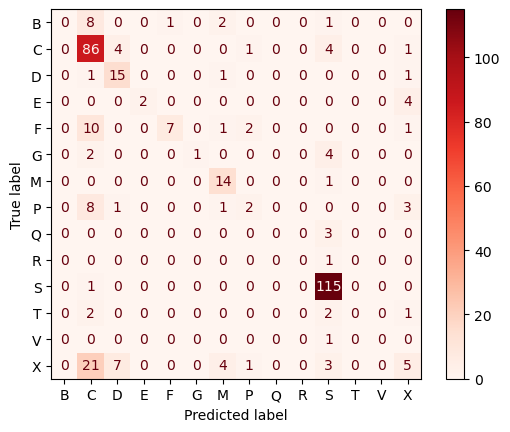

In [39]:
### EXAMPLE SOLUTIONS ###

# Building some random engineered features from the original features, to test how it changes the models

# Adding U-B and B-V to get U-V colors
engfeats_train_S = feats_train_S.copy()
engfeats_train_T = feats_train_T.copy()
engfeats_test_S = feats_test_S.copy()
engfeats_test_T = feats_test_T.copy()

engfeats_train_S["UV"] = engfeats_train_S["UB"] + engfeats_train_S["BV"]
engfeats_test_S["UV"] = engfeats_test_S["UB"] + engfeats_test_S["BV"]
engfeats_train_T["UV"] = engfeats_train_T["UB"] + engfeats_train_T["BV"]
engfeats_test_T["UV"] = engfeats_test_T["UB"] + engfeats_test_T["BV"]

# Altering abedo and H, similar to what was done in linear regression workshop
engfeats_train_S["sqrt_albedo"] = np.sqrt(engfeats_train_S["albedo"])
engfeats_test_S["sqrt_albedo"] = np.sqrt(engfeats_test_S["albedo"])
engfeats_train_T["sqrt_albedo"] = np.sqrt(engfeats_train_T["albedo"])
engfeats_test_T["sqrt_albedo"] = np.sqrt(engfeats_test_T["albedo"])

engfeats_train_S["10^(-H)"] = [10**(-H) for H in engfeats_train_S["H"]]
engfeats_test_S["10^(-H)"] = [10**(-H) for H in engfeats_test_S["H"]]
engfeats_train_T["10^(-H)"] = [10**(-H) for H in engfeats_train_T["H"]]
engfeats_test_T["10^(-H)"] = [10**(-H) for H in engfeats_test_T["H"]]

# Printing DataFrames, just to make sure this worked as expected
display(engfeats_train_S)
display(engfeats_train_T)

# Standardizing the feature scaling using z-scores
engfeats_train_S_scaled = scaler.fit_transform(engfeats_train_S) 
engfeats_test_S_scaled = scaler.fit_transform(engfeats_test_S)
engfeats_train_T_scaled = scaler.fit_transform(engfeats_train_T)
engfeats_test_T_scaled = scaler.fit_transform(engfeats_test_T)

# Setting up the classifier
eng_knn_S = KNeighborsClassifier(n_neighbors=10, algorithm="ball_tree", leaf_size=2, weights="distance")
eng_knn_T = KNeighborsClassifier(n_neighbors=10, algorithm="ball_tree", leaf_size=2, weights="distance")

# Training the classifiers
eng_knn_S.fit(engfeats_train_S_scaled, labels_train_S)
eng_knn_T.fit(engfeats_train_T_scaled, labels_train_T)

# Testing model with rescaled data
eng_predict_test_S = eng_knn_S.predict(engfeats_test_S_scaled)
eng_predict_test_T = eng_knn_T.predict(engfeats_test_T_scaled)

# Plotting feature importances
results = permutation_importance(estimator=eng_knn_S, # your trained model
                                 X = engfeats_train_S_scaled, # data on which the importrance will be computed
                                 y = labels_train_S, # targets for supervised learning
                                 n_repeats = 100, # number of permutations to apply
                                 random_state= 0) # pseudo-random number generator
# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended

print("\n----------------------------")
print("\nSMASSII FEATURE IMPORTANCE (mean +/- std)\n------------------\n")
for i in results.importances_mean.argsort()[::-1]:
        print(f"{engfeats_train_S.columns.tolist()[i]:<15}"
              f"{results.importances_mean[i]:.3f}"
              f" +/- {results.importances_std[i]:.3f}")

results = permutation_importance(estimator=eng_knn_T, # your trained model
                                 X = engfeats_train_T_scaled, # data on which the importrance will be computed
                                 y = labels_train_T, # targets for supervised learning
                                 n_repeats = 100, # number of permutations to apply
                                 random_state= 0) # pseudo-random number generator

# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended

print("\nTHOLEN FEATURE IMPORTANCE (mean +/- std)\n------------------\n")
for i in results.importances_mean.argsort()[::-1]:
        print(f"{engfeats_train_T.columns.tolist()[i]:<15}"
              f"{results.importances_mean[i]:.3f}"
              f" +/- {results.importances_std[i]:.3f}")

eng_acc_S = accuracy_score(labels_test_S, eng_predict_test_S)*100
eng_acc_T = accuracy_score(labels_test_T, eng_predict_test_T)*100

# plotting accuracy
print(f"\n---------------------\nSMASSII Accuracy: {round(eng_acc_S, 1)}% out of {len(eng_predict_test_S)} asteroids")
print(f"Accuracy change: {round(eng_acc_S - acc_S*100,1)}% points")
ConfusionMatrixDisplay.from_predictions(labels_test_S, eng_predict_test_S, cmap="Reds")
plt.show()


print(f"Tholen Accuracy: {round(eng_acc_T, 1)}% out of {len(eng_predict_test_T)} asteroids")
print(f"Accuracy change: {round(eng_acc_T - acc_T*100,1)}% points")
ConfusionMatrixDisplay.from_predictions(labels_test_T, eng_predict_test_T, cmap="Reds")
plt.show()

# Applying the ML model to unclassified asteroids
Once you have a model that you're happy with, you can try it out on new data. Several of the asteroids in the dataset are missing either the SMASSII classification, the Tholen classification, or both. Ideally, a very accurate model could be used to determine their classifications automatically. 

### (OPTIONAL) Objectives: 
- *Use your model(s) to determine the spectral classes of unidentified asteroids in the original dataset.*
- *Compare the SMASS and Tholen classifications. Where do they align? Where do they differ? Can this be explained by the type and amount of data in the set?*


In [ ]:
### Your code here ###
#
#